In [5]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import re
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
# Machine learning tools
from sklearn.model_selection import train_test_split, GridSearchCV

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

nltk.download('punkt')

#Install kagglehu
!pip install -q kagglehub

#download the dataset from kaggle
path = kagglehub.dataset_download("lburleigh/asap-2-0")

print("Dataset downloaded to:")
print(path)

#show the files in the kaggle asap_2.0 dataset
os.listdir(path)

#loading the dataset to google colab
df = pd.read_csv(os.path.join(path, "ASAP2_train_sourcetexts.csv"))





Libraries imported successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


100%|██████████| 21.9M/21.9M [00:00<00:00, 111MB/s] 

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/lburleigh/asap-2-0/versions/8


In [6]:
!pip install textstat language-tool-python scikit-learn nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.1 MB/s eta 0:00:00


In [7]:
print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.columns)
print()
print(df.isnull().sum())
print()
#print(df.duplicated().sum())

               essay_id  score  \
0  AAAVUP14319000159574      4   
1  AAAVUP14319000159542      2   
2  AAAVUP14319000159461      3   
3  AAAVUP14319000159420      2   
4  AAAVUP14319000159419      2   

                                           full_text  \
0  The author suggests that studying Venus is wor...   
1  NASA is fighting to be alble to to go to Venus...   
2  "The Evening Star", is one of the brightest po...   
3  The author supports this idea because from rea...   
4  How the author supports this idea is that he s...   

                                          assignment      prompt_name  \
0  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
1  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
2  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
3  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   
4  In "The Challenge of Exploring Venus," the aut...  Exploring Venus   

       economically

In [8]:
columns_to_keep = [
    "essay_id",
    "score",
    "full_text",
    "assignment",
    "prompt_name"
]

df = df[columns_to_keep]

print(df.head())
print()
print(df.info())
print()
print(df.describe())
print()
print(df.columns)
print()
print(df.isnull().sum())
print()
print(df.duplicated().sum())


df["full_text"] = df["full_text"].str.strip()
df["assignment"] = df["assignment"].str.strip()
df["prompt_name"] = df["prompt_name"].str.strip()

(df["full_text"] == "").sum()
df["score"].value_counts().sort_index()



               essay_id  score  \
0  AAAVUP14319000159574      4   
1  AAAVUP14319000159542      2   
2  AAAVUP14319000159461      3   
3  AAAVUP14319000159420      2   
4  AAAVUP14319000159419      2   

                                           full_text  \
0  The author suggests that studying Venus is wor...   
1  NASA is fighting to be alble to to go to Venus...   
2  "The Evening Star", is one of the brightest po...   
3  The author supports this idea because from rea...   
4  How the author supports this idea is that he s...   

                                          assignment      prompt_name  
0  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
1  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
2  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
3  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  
4  In "The Challenge of Exploring Venus," the aut...  Exploring Venus  

<class 'pandas.core.frame

,count
score,
1,1751
2,6847
3,9021
4,5553
5,1356
6,200


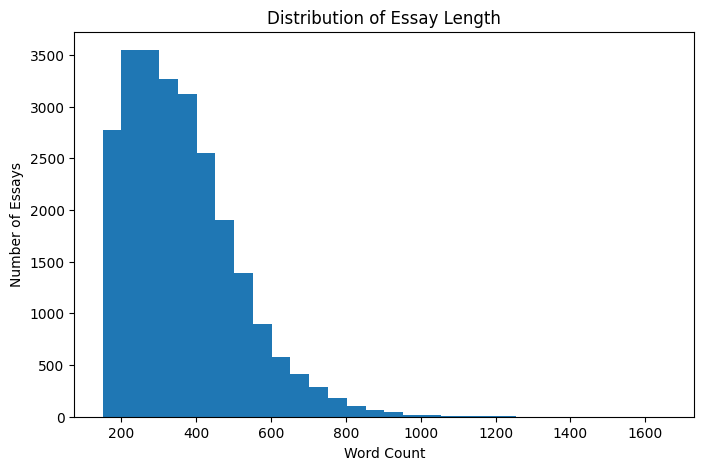

In [9]:
#Feature engineering
df["word_count"] = df["full_text"].apply(lambda x: len(x.split()))
df["word_count"].describe()


plt.figure(figsize=(8,5))
plt.hist(df["word_count"], bins=30)
plt.xlabel("Word Count")
plt.ylabel("Number of Essays")
plt.title("Distribution of Essay Length")
plt.show()

In [10]:
df[df["word_count"] < 20]

df.to_csv("cleaned_asap.csv", index=False)

In [11]:
import re
#Feature engineering
df["character_count"] = df["full_text"].apply(len)

df["sentence_count"] = df["full_text"].apply(lambda x: len(re.findall(r"[.!?]+", x)))

df["avg_sentence_length"] = (df["word_count"] / df["sentence_count"])

df["unique_words"] = df["full_text"].apply(lambda x: len(set(x.lower().split())))


In [12]:
df["unique_words"] = df["full_text"].apply(
    lambda x: len(set(str(x).lower().split()))
)

df["paragraph_count"] = df["full_text"].apply(
    lambda x: len(re.split(r"\n\s*\n", str(x).strip())))

df["avg_word_len"] = (df["character_count"] / df["word_count"])

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

df["stopword_ratio"] = df["full_text"].apply(
    lambda x: sum(1 for w in str(x).lower().split() if w in ENGLISH_STOP_WORDS) / len(str(x).split()))

df["avg_paragraph_len"] = (df["sentence_count"] / df["paragraph_count"])


# Type-Token Ratio (TTR)
# Measures how diverse the vocabulary is in an essay

df["type_token_ratio"] = df.apply(
    lambda row: row["unique_words"] / row["word_count"]
    if row["word_count"] != 0 else 0,
    axis=1
)

df["type_token_ratio"].describe()

,type_token_ratio
count,24728.000000
mean,0.515147
std,0.074006
min,0.054952
25%,0.463312
50%,0.513333
75%,0.565217
max,0.782353


In [13]:
import textstat

# Flesch Reading Ease
df["flesch_reading_ease"] = df["full_text"].apply(
    textstat.flesch_reading_ease
)

# Flesch-Kincaid Grade Level
df["flesch_kincaid_grade"] = df["full_text"].apply(
    textstat.flesch_kincaid_grade
)

# Check the new features
df[[
    "flesch_reading_ease",
    "flesch_kincaid_grade"
]].describe()

,flesch_reading_ease,flesch_kincaid_grade
count,24728.000000,24728.000000
mean,63.409849,9.532290
std,15.888635,5.274198
min,-632.715455,-0.243810
25%,56.645274,7.472333
50%,64.399891,9.000649
75%,71.727028,10.731072
max,108.515000,279.136364


In [14]:
df["full_text"]

,full_text
0,The author suggests that studying Venus is wor...
1,NASA is fighting to be alble to to go to Venus...
2,"""The Evening Star"", is one of the brightest po..."
3,The author supports this idea because from rea...
4,How the author supports this idea is that he s...
...,...
24723,"Hello, my name is STUDENT_NAME. I think driver..."
24724,What you are about to read is going to give yo...
24725,umm yeah just dont drive as much you can save ...
24726,if we look back at time in the united states y...


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Convert essay text into TF-IDF numerical features

tfidf = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)


tfidf_features = tfidf.fit_transform(df["full_text"])

print(tfidf_features.shape)
tfidf_df = pd.DataFrame(
    tfidf_features.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

(24728, 1000)


,000,10,100,12,170,1976,1998,2000,2001,2009,...,worth,worthy,wouldn,wouldnt,wrong,year,years,yes,young,zones
0,0.0,0.0,0.0,0.0,0.081368,0.0,0.0,0.0,0.0,0.0,...,0.0,0.061945,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.125428,0.0,0.0,0.0,0.0,0.0,0.128458,0.0,0.0
2,0.0,0.0,0.0,0.0,0.071123,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.078513,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [16]:
# Select numerical features

numerical_features = df[
    ["word_count",
        "character_count",
        "sentence_count",
        "avg_sentence_length",
        "unique_words",
        "type_token_ratio",
        "flesch_reading_ease",
        "flesch_kincaid_grade"]]


In [17]:
final_features = pd.concat(
    [numerical_features.reset_index(drop=True),
        tfidf_df.reset_index(drop=True)],
    axis=1)

final_features.head()

final_features.shape

(24728, 1008)

In [18]:
# Features
X = final_features

# Target variable (essay score)
y = df["score"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (24728, 1008)
Target shape: (24728,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (19782, 1008)
Testing data: (4946, 1008)


In [20]:
# Find columns containing infinity values

inf_columns = X_train.columns[np.isinf(X_train).any()]

print(inf_columns)

Index(['avg_sentence_length'], dtype='object')


In [21]:
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

In [22]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print(X_train.shape)
print(type(X_train))


(19782, 1008)
<class 'pandas.core.frame.DataFrame'>


In [23]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

print(X_train.shape)
print(type(X_train))


(19782, 1008)
<class 'pandas.core.frame.DataFrame'>


In [24]:
print(np.isinf(X_train).sum().sum())
print(X_train.isnull().sum().sum())

0
0


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [26]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, cohen_kappa_score

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_predicted = ridge.predict(X_test_scaled)


mse = mean_squared_error(y_test, y_predicted)
mae = mean_absolute_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
y_pred_rounded = np.round(y_predicted).astype(int)
qwk = cohen_kappa_score(y_test, y_pred_rounded, weights="quadratic")

print(y_predicted)
print(y_pred_rounded[:10])

print("MSE:", mse)
print("MAE:", mae)
print("R²:", r2)
print("QWK:", qwk)


coef_dict = dict(zip(X_train.columns, ridge.coef_))
print("Coefficient for word_count:", coef_dict["word_count"])



[3.68821587 1.94578944 2.42932498 ... 4.61889916 1.78719743 2.18228738]
[4 2 2 4 3 3 3 2 4 4]
MSE: 0.38617301689997485
MAE: 0.48507836587861847
R²: 0.6374606214658614
QWK: 0.7527025157969172
Coefficient for word_count: -0.7306978091597579


In [27]:
comparison = pd.DataFrame({
    'Actual Score': y_test.values[:10],
    'Predicted Score': y_predicted[:10]})
print("\nSample Predictions (First 10 Essays):")
print(comparison.round(2))


Sample Predictions (First 10 Essays):
   Actual Score  Predicted Score
0             3             3.69
1             2             1.95
2             2             2.43
3             3             3.91
4             2             2.56
5             4             3.45
6             1             2.67
7             2             2.19
8             3             4.21
9             5             4.35


In [28]:
#Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, cohen_kappa_score

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

mse_gb = mean_squared_error(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

y_pred_gb_rounded = np.round(y_pred_gb).astype(int)
qwk_gb = cohen_kappa_score(y_test, y_pred_gb_rounded, weights="quadratic")

print("MSE: ", mse_gb)
print("Mean Absolute error: ", mae_gb)
print("R square score: ", r2_score)
print("QWK: ", qwk_gb)



MSE:  0.3970677217392951
Mean Absolute error:  0.48219606492201506
R square score:  <function r2_score at 0x7ad0a78cf100>
QWK:  0.7329587499104186



Sample Predictions (First 10 Essays):
   Actual Score  Predicted Score
0             3             3.71
1             2             2.28
2             2             2.36
3             3             3.91
4             2             1.97
5             4             3.46
6             1             3.41
7             2             1.96
8             3             3.98
9             5             4.65


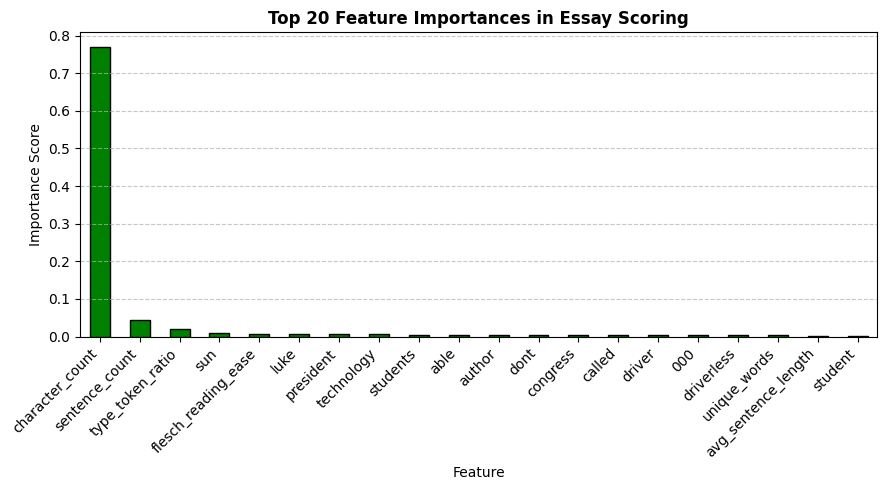

In [29]:
comparison_df = pd.DataFrame({
    'Actual Score': y_test.values[:10],
    'Predicted Score': y_pred_gb[:10]})
print("\nSample Predictions (First 10 Essays):")
print(comparison_df.round(2))

# 5. Feature importance — top 20 only, for readability
importances = pd.Series(gb_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 5))
importances.plot(kind='bar', color='green', edgecolor='black')
plt.title("Top 20 Feature Importances in Essay Scoring", fontsize=12, fontweight='bold')
plt.xlabel("Feature", fontsize=10)
plt.ylabel("Importance Score", fontsize=10)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [30]:
# Random Forest model
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

# Create baseline Random Forest model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created!")

Libraries imported successfully!
Random Forest model created!


In [31]:
"""rf_model.fit(X_train, y_train)

print("Model training completed!")"""

'rf_model.fit(X_train, y_train)\n\nprint("Model training completed!")'

In [32]:
# Make predictions on test data

"""y_pred = rf_model.predict(X_test)

print(y_pred[:10])

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate metrics

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)"""


'y_pred = rf_model.predict(X_test)\n\nprint(y_pred[:10])\n\nfrom sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score\n\n# Calculate metrics\n\nmse = mean_squared_error(y_test, y_pred)\nmae = mean_absolute_error(y_test, y_pred)\nr2 = r2_score(y_test, y_pred)\n\nprint("Mean Squared Error:", mse)\nprint("Mean Absolute Error:", mae)\nprint("R² Score:", r2)'

In [33]:
from sklearn.metrics import cohen_kappa_score

# Round predictions because essay scores are whole numbers
"""y_pred_rounded = np.round(y_pred).astype(int)

print(y_pred_rounded[:10])

# Calculate Quadratic Weighted Kappa
qwk = cohen_kappa_score(
    y_test,
    y_pred_rounded,
    weights="quadratic")

print("Quadratic Weighted Kappa (QWK):", qwk)"""

'y_pred_rounded = np.round(y_pred).astype(int)\n\nprint(y_pred_rounded[:10])\n\n# Calculate Quadratic Weighted Kappa\nqwk = cohen_kappa_score(\n    y_test,\n    y_pred_rounded,\n    weights="quadratic")\n\nprint("Quadratic Weighted Kappa (QWK):", qwk)'

In [34]:
"""comparison_rf = pd.DataFrame({
    'Actual Score': y_test.values[:10],
    'Predicted Score': y_pred[:10]})
print("\nSample Predictions (First 10 Essays):")
print(comparison_rf.round(2))"""

'comparison_rf = pd.DataFrame({\n    \'Actual Score\': y_test.values[:10],\n    \'Predicted Score\': y_pred[:10]})\nprint("\nSample Predictions (First 10 Essays):")\nprint(comparison_rf.round(2))'

In [35]:
# Get feature importance scores

"""feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_})

# Sort from most important to least important

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False)

# Display top 20 features

feature_importance.head(20)"""


'feature_importance = pd.DataFrame({\n    "Feature": X_train.columns,\n    "Importance": rf_model.feature_importances_})\n\n# Sort from most important to least important\n\nfeature_importance = feature_importance.sort_values(\n    by="Importance",\n    ascending=False)\n\n# Display top 20 features\n\nfeature_importance.head(20)'

In [36]:
"""plt.figure(figsize=(10,6))

plt.barh(
    feature_importance.head(20)["Feature"],
    feature_importance.head(20)["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()"""

'plt.figure(figsize=(10,6))\n\nplt.barh(\n    feature_importance.head(20)["Feature"],\n    feature_importance.head(20)["Importance"])\n\nplt.xlabel("Importance")\nplt.ylabel("Feature")\nplt.title("Top 20 Random Forest Feature Importance")\n\nplt.gca().invert_yaxis()\n\nplt.show()'

In [37]:

from sklearn.model_selection import GridSearchCV
"""param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5]}"""

'param_grid = {\n    "n_estimators": [100, 200],\n    "max_depth": [None, 10, 20],\n    "min_samples_leaf": [1, 2, 5]}'

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

"""models = {
    "RF_100_trees": RandomForestRegressor(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1),

    "RF_200_trees": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1),

    "RF_depth20_leaf2": RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1)}"""



'models = {\n    "RF_100_trees": RandomForestRegressor(\n        n_estimators=100,\n        max_depth=None,\n        min_samples_leaf=1,\n        random_state=42,\n        n_jobs=-1),\n\n    "RF_200_trees": RandomForestRegressor(\n        n_estimators=200,\n        max_depth=None,\n        min_samples_leaf=1,\n        random_state=42,\n        n_jobs=-1),\n\n    "RF_depth20_leaf2": RandomForestRegressor(\n        n_estimators=100,\n        max_depth=20,\n        min_samples_leaf=2,\n        random_state=42,\n        n_jobs=-1)}'

In [39]:
"""plt.figure(figsize=(10,8))

top20 = feature_importance.head(20)

plt.barh(top20["Feature"], top20["Importance"])

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 20 Most Important Features in the Random Forest Model")

plt.gca().invert_yaxis()

plt.show()"""

'plt.figure(figsize=(10,8))\n\ntop20 = feature_importance.head(20)\n\nplt.barh(top20["Feature"], top20["Importance"])\n\nplt.xlabel("Importance Score")\nplt.ylabel("Feature")\nplt.title("Top 20 Most Important Features in the Random Forest Model")\n\nplt.gca().invert_yaxis()\n\nplt.show()'

In [40]:
"""results = pd.DataFrame({
    "Metric": [
        "Mean Squared Error (MSE)",
        "Mean Absolute Error (MAE)",
        "R² Score",
        "Quadratic Weighted Kappa (QWK)"
    ],
    "Value": [
        mse,
        mae,
        r2,
        qwk
    ]})

results"""

'results = pd.DataFrame({\n    "Metric": [\n        "Mean Squared Error (MSE)",\n        "Mean Absolute Error (MAE)",\n        "R² Score",\n        "Quadratic Weighted Kappa (QWK)"\n    ],\n    "Value": [\n        mse,\n        mae,\n        r2,\n        qwk\n    ]})\n\nresults'

In [41]:
!pip install nltk spacy textstat language-tool-python yake


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 20.4 MB/s eta 0:00:00


In [42]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [43]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 37.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [44]:
import pandas as pd
import numpy as np
import re

import nltk
import spacy

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords

nlp = spacy.load("en_core_web_sm")

In [45]:
#POS function
def pos_features(text):

    doc = nlp(str(text))

    counts = {
        "noun_count": 0,
        "verb_count": 0,
        "adjective_count": 0,
        "adverb_count": 0,
        "pronoun_count": 0,
        "determiner_count": 0,
        "preposition_count": 0,
        "conjunction_count": 0
    }

    for token in doc:

        if token.pos_ == "NOUN":
            counts["noun_count"] += 1

        elif token.pos_ == "VERB":
            counts["verb_count"] += 1

        elif token.pos_ == "ADJ":
            counts["adjective_count"] += 1

        elif token.pos_ == "ADV":
            counts["adverb_count"] += 1

        elif token.pos_ == "PRON":
            counts["pronoun_count"] += 1

        elif token.pos_ == "DET":
            counts["determiner_count"] += 1

        elif token.pos_ == "ADP":
            counts["preposition_count"] += 1

        elif token.pos_ == "CCONJ":
            counts["conjunction_count"] += 1

    return pd.Series(counts)

In [46]:
#
pos_df = df["full_text"].apply(pos_features)

print(pos_df.head())
print(pos_df.shape)

   noun_count  verb_count  adjective_count  adverb_count  pronoun_count  \
0          80          53               41            29             39   
1          39          23               11            10             15   
2          85          35               28            19             22   
3          54          18               20             9             14   
4          50          34               12            14             17   

   determiner_count  preposition_count  conjunction_count  
0                25                 44                 13  
1                15                 28                  9  
2                39                 45                 13  
3                25                 31                  7  
4                18                 22                 11  
(24728, 8)


In [47]:
df = pd.concat([df, pos_df], axis=1)

In [48]:
print(df.columns.tolist())

['essay_id', 'score', 'full_text', 'assignment', 'prompt_name', 'word_count', 'character_count', 'sentence_count', 'avg_sentence_length', 'unique_words', 'paragraph_count', 'avg_word_len', 'stopword_ratio', 'avg_paragraph_len', 'type_token_ratio', 'flesch_reading_ease', 'flesch_kincaid_grade', 'noun_count', 'verb_count', 'adjective_count', 'adverb_count', 'pronoun_count', 'determiner_count', 'preposition_count', 'conjunction_count']


In [49]:
print(df[
    ["noun_count",
        "verb_count",
        "adjective_count",
        "adverb_count",
        "pronoun_count"]].head())

   noun_count  verb_count  adjective_count  adverb_count  pronoun_count
0          80          53               41            29             39
1          39          23               11            10             15
2          85          35               28            19             22
3          54          18               20             9             14
4          50          34               12            14             17


In [50]:
#POS ratios
pos_columns = [
    "noun_count",
    "verb_count",
    "adjective_count",
    "adverb_count",
    "pronoun_count",
    "determiner_count",
    "preposition_count",
    "conjunction_count"]

for col in pos_columns:

    df[col + "_ratio"] = (df[col] / df["word_count"].replace(0, np.nan))

In [51]:
final_features = pd.concat([final_features.reset_index(drop=True),
        pos_df.reset_index(drop=True)],axis=1)

print("Final feature shape:", final_features.shape)

Final feature shape: (24728, 1016)


In [52]:
df[pos_columns] = df[pos_columns].fillna(0)

In [53]:
#Lexical features

def lexical_features(text, window=50):
  #window(divides each section into 50 words)

    words = [w.lower()
        for w in word_tokenize(str(text))
        #w.isalpha(keep words only if it contains only alphabets)
        if w.isalpha()]

    if len(words) == 0:
        return pd.Series({
            "unique_word_count": 0,
            "type_token_ratio": 0,
            "mattr": 0})

    unique_words = len(set(words))
#ttr(type token ratio)
    ttr = unique_words / len(words)

    if len(words) < window:
        mattr = ttr
    else:
        ratios = []

        for i in range(len(words) - window + 1):

            section = words[i:i + window]

            ratios.append(len(set(section)) / window)
#mattr(moving average type token ratio)
        mattr = np.mean(ratios)

    return pd.Series({
        "unique_word_count": unique_words,
        "type_token_ratio": ttr,
        "mattr": mattr})

In [54]:
#Keyword Extraction
import yake

keyword_extractor = yake.KeywordExtractor(
    lan="en",
    n=2,
    dedupLim=0.9,
    top=10)

def extract_keywords(text):

    keywords = keyword_extractor.extract_keywords(str(text))

    return [keyword for keyword, score in keywords]
sample_keywords = extract_keywords(df["full_text"].iloc[0])

print(sample_keywords)


def keyword_count(text):

    keywords = keyword_extractor.extract_keywords(str(text))

    return len(keywords)



['degrees Fahrenheit', 'Venus', 'author suggests', 'studying Venus', 'Venus surface', 'author', 'Fahrenheit', 'conditions', 'surface', 'planet']


In [55]:
df["keyword_count"] = df["full_text"].apply(keyword_count)



In [ ]:
df["keyword_density"] = (
    df["keyword_count"] /
    df["word_count"].replace(0, np.nan))


In [ ]:
df["keyword_density"] = df["keyword_density"].fillna(0)

In [58]:
#NER(Named entity recognition)
def ner_features(text):

    doc = nlp(str(text))

    entities = doc.ents

    return pd.Series({
        "entity_count": len(entities),
        "person_count": sum(ent.label_ == "PERSON" for ent in entities),
        "organization_count": sum(ent.label_ == "ORG" for ent in entities),
        "location_count": sum(ent.label_ == "GPE" for ent in entities),
        "date_count": sum(ent.label_ == "DATE" for ent in entities)})


In [59]:
ner_df = df["full_text"].apply(ner_features)

df = pd.concat([df, ner_df], axis=1)

In [ ]:
#Grammar
import language_tool_python

tool = language_tool_python.LanguageTool("en-US")

sample = df["full_text"].iloc[0]
matches = tool.check(sample)
print("Errors:", len(matches))

def grammar_error_count(text):
    matches = tool.check(str(text))

    return len(matches)

In [ ]:
   df["grammar_errors"] = df["full_text"].apply(
    grammar_error_count)

In [ ]:
for match in matches[:10]:

    print(match.ruleId)
    print(match.message)
    print()

In [ ]:
linguistic_features = [
    "word_count",
    "sentence_count",
    "character_count",
    "paragraph_count",
    "avg_word_length",
    "avg_sentence_length",
    "unique_words",
    "type_token_ratio",
    "stopword_ratio",
    "flesch_reading_ease",
    "flesch_kincaid_grade",

    "noun_count",
    "verb_count",
    "adjective_count",
    "adverb_count",
    "pronoun_count",
    "determiner_count",
    "preposition_count",
    "conjunction_count",

    "noun_ratio",
    "verb_ratio",
    "adjective_ratio",
    "adverb_ratio",
    "pronoun_ratio",

    "mattr",

    "keyword_count",
    "keyword_density",

    "entity_count",
    "person_count",
    "organization_count",
    "location_count",
    "date_count",

    "grammar_errors"]

In [ ]:
final_features = df[
    linguistic_features
].copy()



In [ ]:
print(final_features.shape)
print(final_features.head())
print(final_features.isnull().sum().sum())

In [ ]:
final_features.to_csv(
    "linguistic_features.csv",
    index=False
)